# CNM + Primordial + Experimental (LHC) Step-by-Step

Notebook workflow for publication plots with explicit staged steps, matching the CNM production style:
1. setup and configuration
2. primordial build/load (state-dependent)
3. CNM build per state
4. `R_{pA}` vs centrality
5. `R_{pA}` vs `y`
6. `R_{pA}` vs `p_T`
7. CSV/PDF export

Defaults:
- LHC baseline CNM uses **no nuclear absorption**
- Colors: CNM gray, Primordial Pert dashed blue, Primordial NPWLC dashed green,
  CNM×Prim Pert solid blue, CNM×Prim NPWLC solid green


## Step 0: Setup


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np

project = Path.cwd()
if not (project / 'cnm_primordial_notebooks').exists():
    project = project.parent

sys.path.insert(0, str(project / 'cnm_primordial_notebooks'))
import cnm_primordial_publication_lib as pub

pub.configure_matplotlib()
print('Project:', project)


Project: /home/sawin/Desktop/Charmonia/charmonia_combined_analysis


## Step 1: Analysis Configuration (edit here)


In [2]:
SYSTEM = 'LHC'
ENERGY = '8.16'     # choose: '5.02' or '8.16'
FORMATION = 'radius' # choose: 'radius', 'new', 'old'

STATES = ['jpsi_1S', 'psi_2S']

# LHC default baseline: no nuclear absorption in CNM total
USE_ABSORPTION_PRIMARY = False
SHOW_ALT_CNM = False

INCLUDE_PRIMORDIAL = True
INCLUDE_COMBINED = True
SHOW_CNM_COMPONENTS = False  # optional: npdf/eloss/broad/eloss_broad overlays
BAND_MODE = 'quadrature'     # 'quadrature' or 'envelope'
INCLUDE_EXPERIMENT = True


# Manual plot-range / legend controls (publication tuning)
CENT_XLIM = (0.0, 100.0)
CENT_YLIM = (0.0, 1.6)
Y_XLIM = (-5.0, 5.0)
Y_YLIM = (0.0, 1.6)
PT_XLIM = (0.0, 20.0)
PT_YLIM = (0.0, 1.6)

CENT_LEGEND_LOC = 'lower center'
CENT_LEGEND_NCOL = 2

Y_LEGEND_LOCATION = 'bottom'   # 'top' or 'bottom'
Y_LEGEND_REPEAT = False
Y_LEGEND_NCOL = 2
Y_LEGEND_BOLD = False

PT_NOTE_LOC_FIRST = 'lower right'


# Easy style knobs
THEORY_STYLE_OVERRIDES = {
    'prim_pert': {'color': 'tab:red', 'ls': '--', 'label': 'TAMU-P'},
    'prim_npwlc': {'label': 'TAMU-NP'},
    'comb_pert': {'color': 'tab:red', 'ls': '-', 'label': r'CNM$\times$TAMU-P'},
    'comb_npwlc': {'label': r'CNM$\times$TAMU-NP'},
}
COMPONENT_STYLE_OVERRIDES = {
    # keep component palette distinct from Pert red/NPWLC green
    'eloss': {'color': '#8C564B'},
}
TEXT_STYLE_OVERRIDES = {
    'system_color': '#0B3D91',
    'state_color': 'black',
    'tag_color': '#1F77B4',
    'system_fontsize': 11.0,
    'state_fontsize': 11.0,
    'tag_fontsize': 10.0,
    'note_fontsize': 9.3,
}

LEGEND_FONT_SIZE = 8.2
PT_LEGEND_SPLIT = True

PT_MASTERGRID = True
PT_MASTERGRID_XLIM = PT_XLIM
PT_MASTERGRID_YLIM = PT_YLIM
PT_MASTERGRID_LEGEND_SPLIT = True



SAVE_PDF = True
SAVE_PNG = False

out_root = project / 'outputs' / 'combined_cnm_primordial_experimental' / f"LHC_{ENERGY.replace('.', 'p')}TeV" / FORMATION / 'step_by_step'
out_root.mkdir(parents=True, exist_ok=True)
out_root


PosixPath('/home/sawin/Desktop/Charmonia/charmonia_combined_analysis/outputs/combined_cnm_primordial_experimental/LHC_8p16TeV/radius/step_by_step')

## Step 2: Build System Setup


In [3]:
pub.apply_style_overrides(
    theory_style_overrides=THEORY_STYLE_OVERRIDES,
    component_style_overrides=COMPONENT_STYLE_OVERRIDES,
    text_style_overrides=TEXT_STYLE_OVERRIDES,
)

setup = pub.get_system_setup(SYSTEM, ENERGY)
setup


SystemSetup(system='LHC', energy='8.16', cent_bins=[(0, 20), (20, 40), (40, 60), (60, 80), (80, 100)], y_windows={'backward': (-4.46, -2.96), 'central': (-1.37, 0.43), 'forward': (2.03, 3.53)}, y_edges=array([-5. , -4.5, -4. , -3.5, -3. , -2.5, -2. , -1.5, -1. , -0.5,  0. ,
        0.5,  1. ,  1.5,  2. ,  2.5,  3. ,  3.5,  4. ,  4.5,  5. ]), pt_edges=array([ 0. ,  2.5,  5. ,  7.5, 10. , 12.5, 15. , 17.5, 20. ]), pt_range_integrated=(0.0, 15.0), r_label='$R_{pA}$')

## Step 3: Build/Load Primordial Products


In [4]:
prim = pub.build_primordial_products(setup, FORMATION, STATES)
print('Primordial available:', prim.available)
print('Reason:', prim.reason)


Primordial available: True
Reason: ok


## Step 4: Build CNM Products Per State


In [5]:
cnm_by_state = {}
for st in STATES:
    print(f'Building CNM for {st} ...')
    cnm_by_state[st] = pub.build_cnm_state_products(
        setup,
        st,
        use_absorption_primary=USE_ABSORPTION_PRIMARY,
        include_cnm_components=SHOW_CNM_COMPONENTS,
    )

pub.summarize_products(cnm_by_state, prim)


Building CNM for jpsi_1S ...
Building CNM for psi_2S ...


,state,primary_variant,n_y_bins,n_pt_bins,n_cent_bins,primordial_available
0,jpsi_1S,no_abs,20,8,5,True
1,psi_2S,no_abs,20,8,5,True


## Step 5: Plot Family A - $R_{pA}$ vs Centrality (3 rapidity windows + MB reference bands)


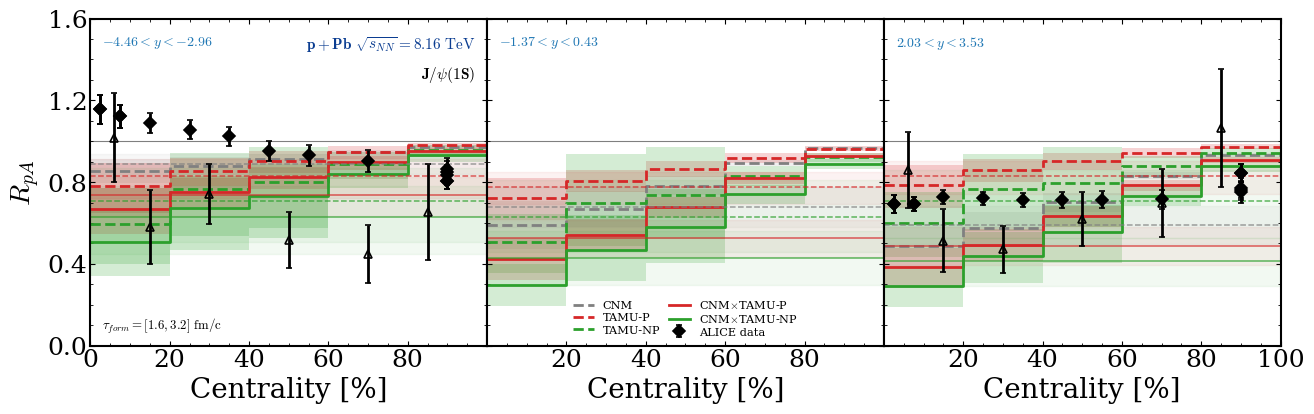

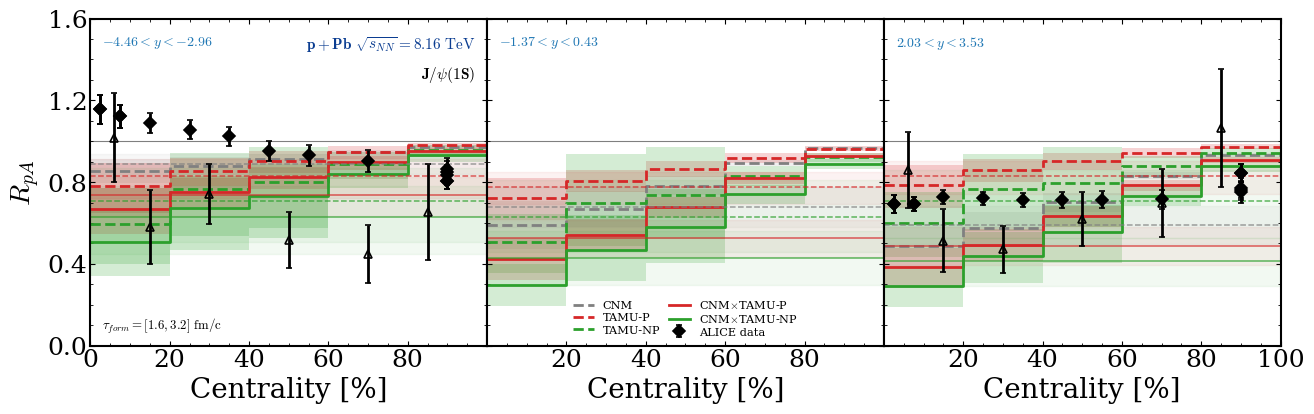

In [6]:
rows_cent = []
if SYSTEM == 'LHC':
    st = STATES[0]
    fig, rows = pub.plot_state_vs_centrality(
        setup=setup,
        formation=FORMATION,
        state=st,
        cnm=cnm_by_state[st],
        prim=prim,
        include_primordial=INCLUDE_PRIMORDIAL,
        include_combined=INCLUDE_COMBINED,
        show_cnm_components=SHOW_CNM_COMPONENTS,
        show_alt_cnm=SHOW_ALT_CNM,
        band_mode=BAND_MODE,
        include_experiment=INCLUDE_EXPERIMENT,
        xlim=CENT_XLIM,
        ylim=CENT_YLIM,
        legend_loc=CENT_LEGEND_LOC,
        legend_ncol=CENT_LEGEND_NCOL,
        legend_fontsize=LEGEND_FONT_SIZE,
        text_style=TEXT_STYLE_OVERRIDES,
    )
    if INCLUDE_EXPERIMENT and len(STATES) > 1:
        for ax, (_, y0, y1) in zip(fig.axes, pub.iter_ywins(setup.y_windows)):
            pub.overlay_lhc_state(ax, 'vs_centrality', ENERGY, 'psi_2S', rap_window=(y0, y1))
    pub.save_figure(fig, out_root / 'RpA_vs_centrality', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
    rows_cent.extend(rows)
    display(fig)
else:
    for st in STATES:
        fig, rows = pub.plot_state_vs_centrality(
            setup=setup,
            formation=FORMATION,
            state=st,
            cnm=cnm_by_state[st],
            prim=prim,
            include_primordial=INCLUDE_PRIMORDIAL,
            include_combined=INCLUDE_COMBINED,
            show_cnm_components=SHOW_CNM_COMPONENTS,
            show_alt_cnm=SHOW_ALT_CNM,
            band_mode=BAND_MODE,
            include_experiment=INCLUDE_EXPERIMENT,
            xlim=CENT_XLIM,
            ylim=CENT_YLIM,
            legend_loc=CENT_LEGEND_LOC,
            legend_ncol=CENT_LEGEND_NCOL,
            legend_fontsize=LEGEND_FONT_SIZE,
            text_style=TEXT_STYLE_OVERRIDES,
        )
        pub.save_figure(fig, out_root / f'RpA_vs_centrality_{st}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
        rows_cent.extend(rows)
        display(fig)


## Step 6: Plot Family B - $R_{pA}$ vs $y$ (each centrality + MB panel)


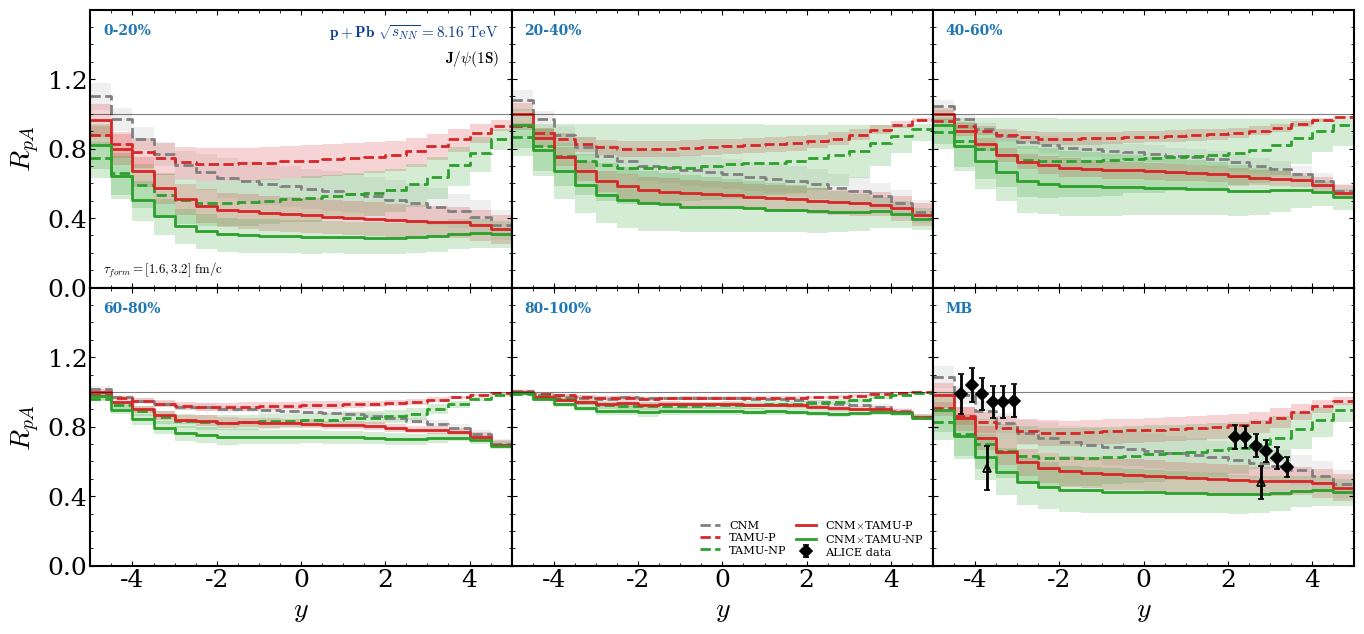

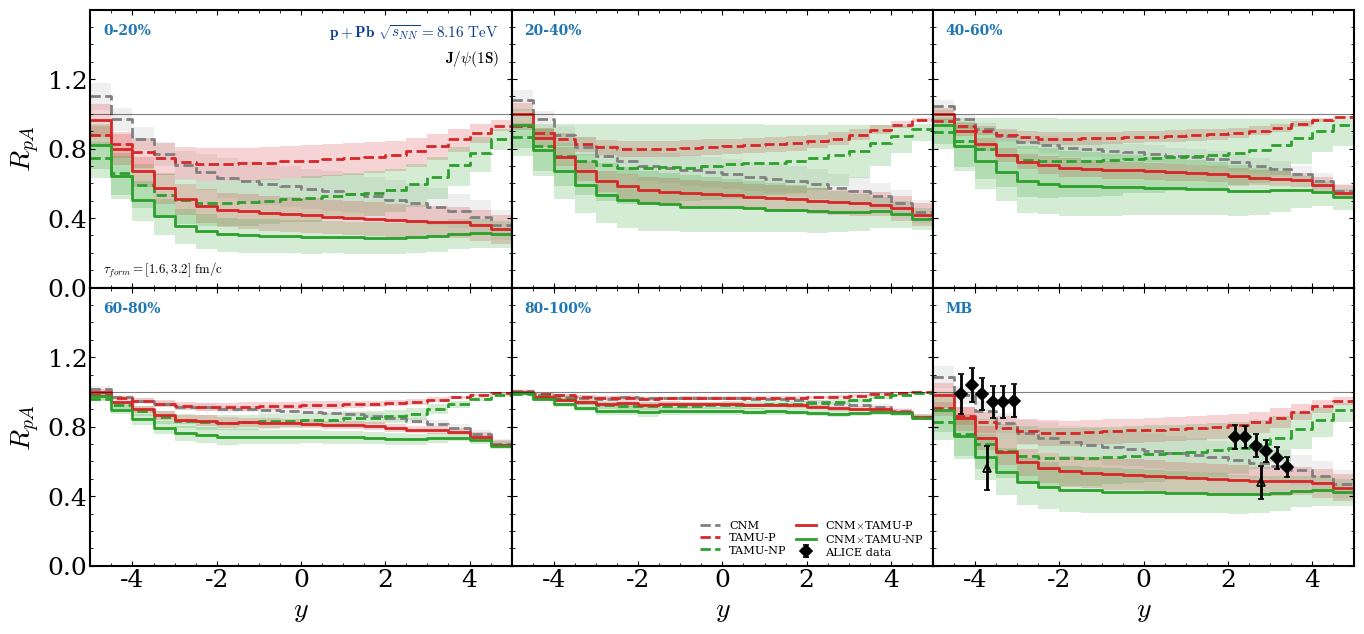

In [7]:
rows_y = []
if SYSTEM == 'LHC':
    st = STATES[0]
    fig, rows = pub.plot_state_vs_y(
        setup=setup,
        formation=FORMATION,
        state=st,
        cnm=cnm_by_state[st],
        prim=prim,
        include_primordial=INCLUDE_PRIMORDIAL,
        include_combined=INCLUDE_COMBINED,
        show_cnm_components=SHOW_CNM_COMPONENTS,
        show_alt_cnm=SHOW_ALT_CNM,
        band_mode=BAND_MODE,
        include_experiment=INCLUDE_EXPERIMENT,
        xlim=Y_XLIM,
        ylim=Y_YLIM,
        legend_location=Y_LEGEND_LOCATION,
        legend_repeat=Y_LEGEND_REPEAT,
        legend_ncol=Y_LEGEND_NCOL,
        legend_bold=Y_LEGEND_BOLD,
        legend_fontsize=LEGEND_FONT_SIZE,
        text_style=TEXT_STYLE_OVERRIDES,
    )
    if INCLUDE_EXPERIMENT and len(STATES) > 1:
        cent_tags = [pub.canonical_cent(f"{a}-{b}%") for (a, b) in setup.cent_bins] + ['MB']
        axes = list(fig.axes)
        for idx, tag in enumerate(cent_tags):
            if tag == 'MB' and idx < len(axes):
                pub.overlay_lhc_state(axes[idx], 'vs_y', ENERGY, 'psi_2S')
    pub.save_figure(fig, out_root / 'RpA_vs_y', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
    rows_y.extend(rows)
    display(fig)
else:
    for st in STATES:
        fig, rows = pub.plot_state_vs_y(
            setup=setup,
            formation=FORMATION,
            state=st,
            cnm=cnm_by_state[st],
            prim=prim,
            include_primordial=INCLUDE_PRIMORDIAL,
            include_combined=INCLUDE_COMBINED,
            show_cnm_components=SHOW_CNM_COMPONENTS,
            show_alt_cnm=SHOW_ALT_CNM,
            band_mode=BAND_MODE,
            include_experiment=INCLUDE_EXPERIMENT,
            xlim=Y_XLIM,
            ylim=Y_YLIM,
            legend_location=Y_LEGEND_LOCATION,
            legend_repeat=Y_LEGEND_REPEAT,
            legend_ncol=Y_LEGEND_NCOL,
            legend_bold=Y_LEGEND_BOLD,
            legend_fontsize=LEGEND_FONT_SIZE,
            text_style=TEXT_STYLE_OVERRIDES,
        )
        pub.save_figure(fig, out_root / f'RpA_vs_y_{st}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
        rows_y.extend(rows)
        display(fig)


## Step 7: Plot Family C - $R_{pA}$ vs $p_T$ (for each rapidity, with centrality panels + MB)


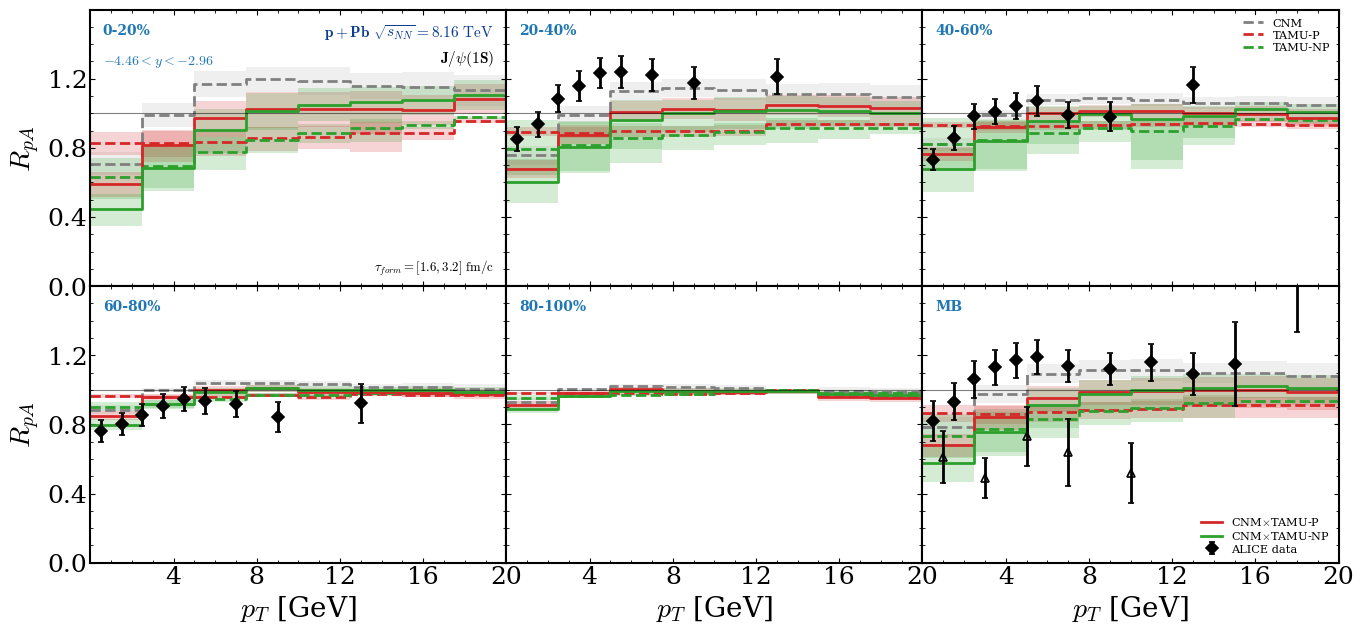

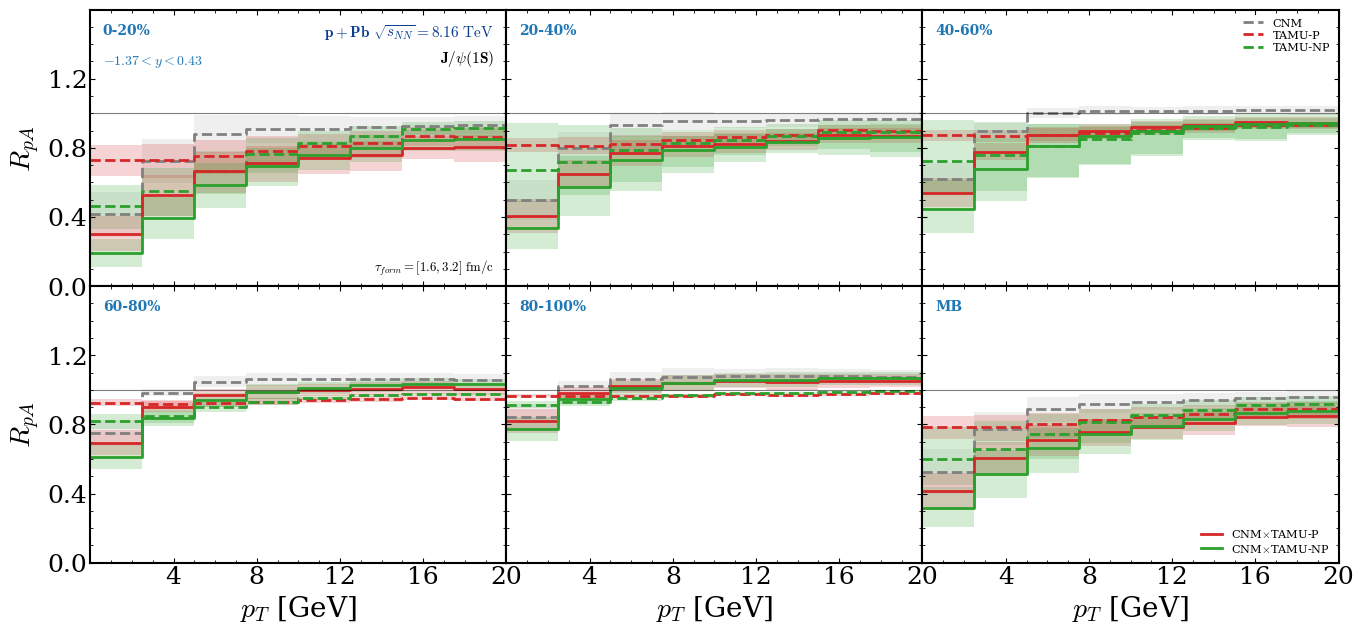

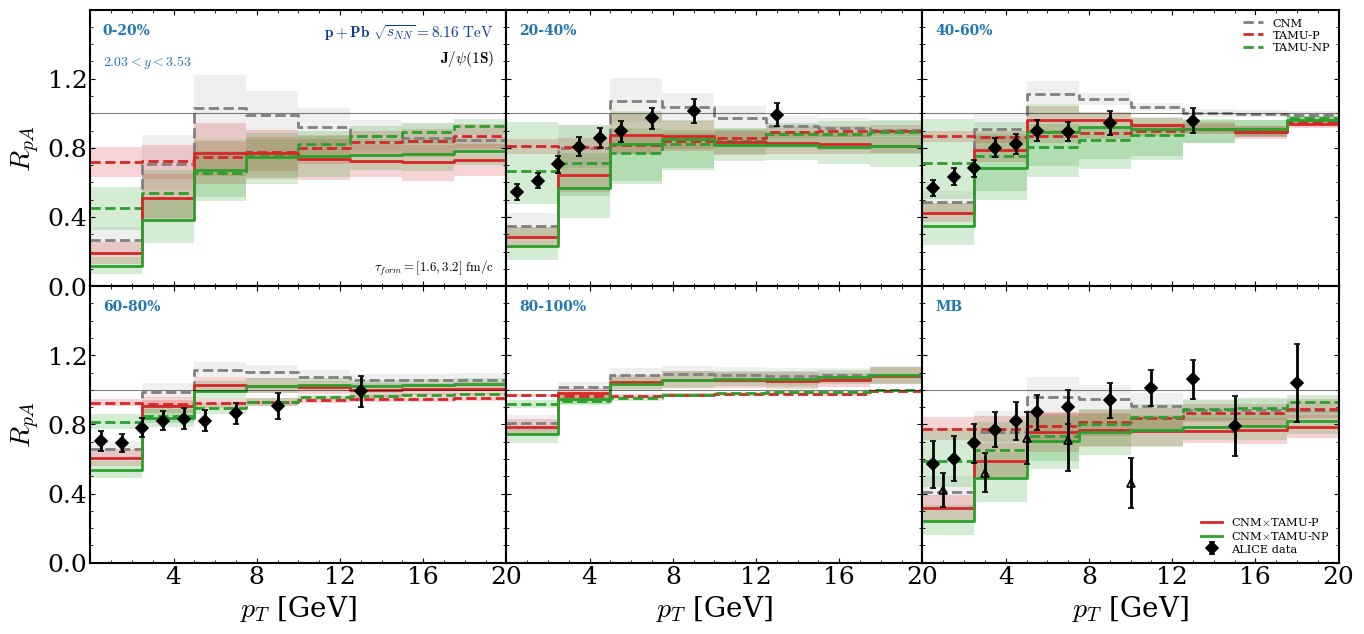

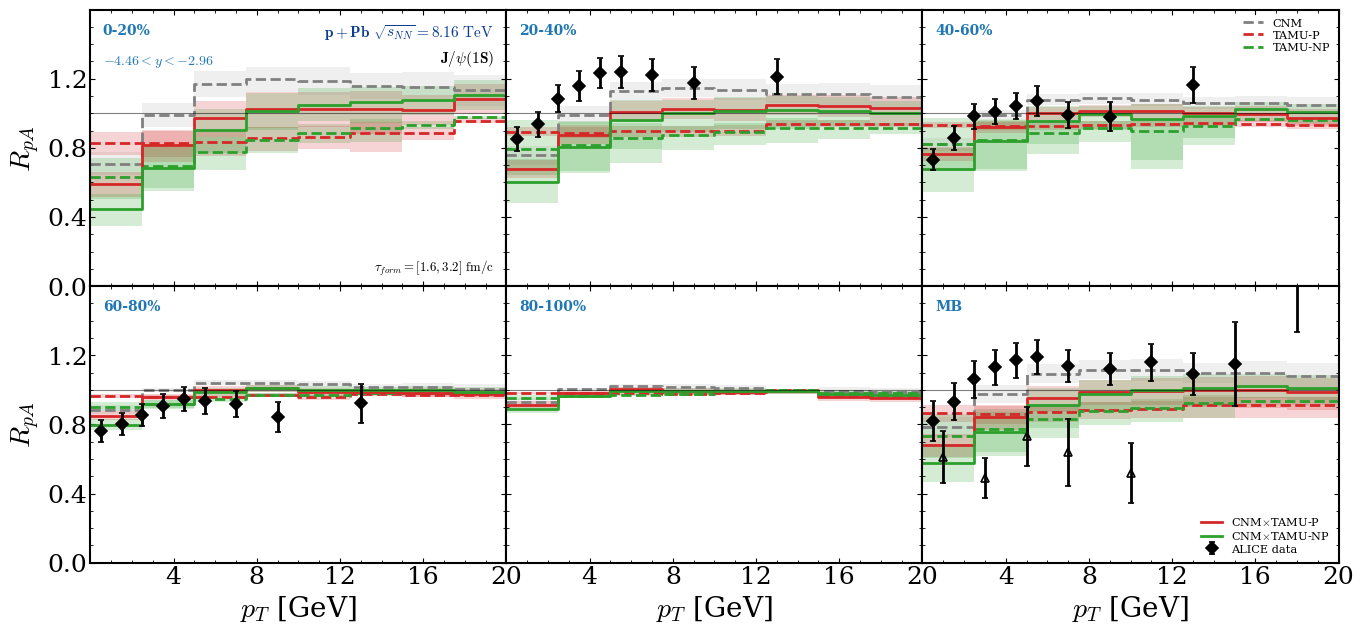

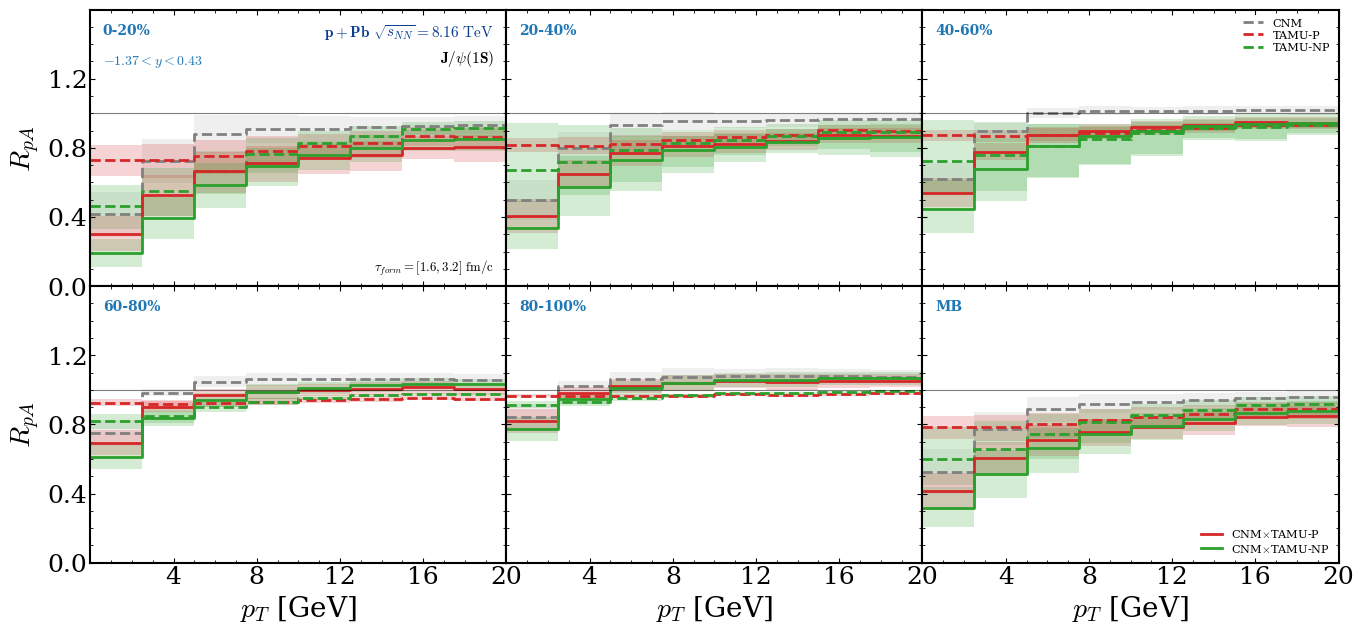

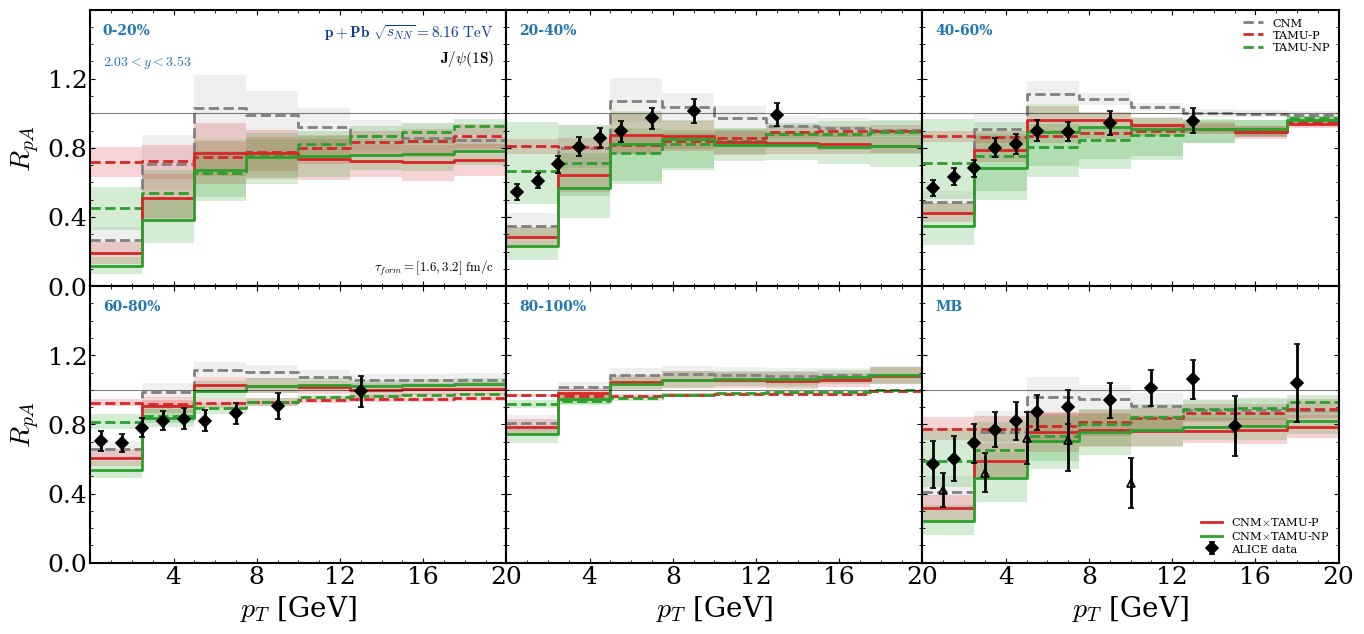

In [8]:
rows_pt = []
if SYSTEM == 'LHC':
    st = STATES[0]
    by_y = pub.plot_state_vs_pt(
        setup=setup,
        formation=FORMATION,
        state=st,
        cnm=cnm_by_state[st],
        prim=prim,
        include_primordial=INCLUDE_PRIMORDIAL,
        include_combined=INCLUDE_COMBINED,
        show_cnm_components=SHOW_CNM_COMPONENTS,
        show_alt_cnm=SHOW_ALT_CNM,
        band_mode=BAND_MODE,
        include_experiment=INCLUDE_EXPERIMENT,
        xlim=PT_XLIM,
        ylim=PT_YLIM,
        note_loc_first=PT_NOTE_LOC_FIRST,
        legend_split=PT_LEGEND_SPLIT,
        legend_fontsize=LEGEND_FONT_SIZE,
        legend_bold=False,
        text_style=TEXT_STYLE_OVERRIDES,
    )
    for yname, (fig, rows) in by_y.items():
        if INCLUDE_EXPERIMENT and len(STATES) > 1:
            rap_window = setup.y_windows[yname]
            cent_tags = [pub.canonical_cent(f"{a}-{b}%") for (a, b) in setup.cent_bins] + ['MB']
            axes = list(fig.axes)
            for idx, cent_tag in enumerate(cent_tags):
                if idx >= len(axes):
                    break
                if cent_tag == 'MB':
                    pub.overlay_lhc_state(axes[idx], 'vs_pt', ENERGY, 'psi_2S', rap_window=rap_window, cent_tag='MB')
                else:
                    pub.overlay_lhc_state(axes[idx], 'vs_pt_cent', ENERGY, 'psi_2S', rap_window=rap_window, cent_tag=cent_tag)
        pub.save_figure(fig, out_root / f'RpA_vs_pT_{yname}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
        rows_pt.extend(rows)
        display(fig)
else:
    for st in STATES:
        by_y = pub.plot_state_vs_pt(
            setup=setup,
            formation=FORMATION,
            state=st,
            cnm=cnm_by_state[st],
            prim=prim,
            include_primordial=INCLUDE_PRIMORDIAL,
            include_combined=INCLUDE_COMBINED,
            show_cnm_components=SHOW_CNM_COMPONENTS,
            show_alt_cnm=SHOW_ALT_CNM,
            band_mode=BAND_MODE,
            include_experiment=INCLUDE_EXPERIMENT,
            xlim=PT_XLIM,
            ylim=PT_YLIM,
            note_loc_first=PT_NOTE_LOC_FIRST,
            legend_split=PT_LEGEND_SPLIT,
            legend_fontsize=LEGEND_FONT_SIZE,
            legend_bold=False,
            text_style=TEXT_STYLE_OVERRIDES,
        )
        for yname, (fig, rows) in by_y.items():
            pub.save_figure(fig, out_root / f'RpA_vs_pT_{st}_{yname}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
            rows_pt.extend(rows)
            display(fig)


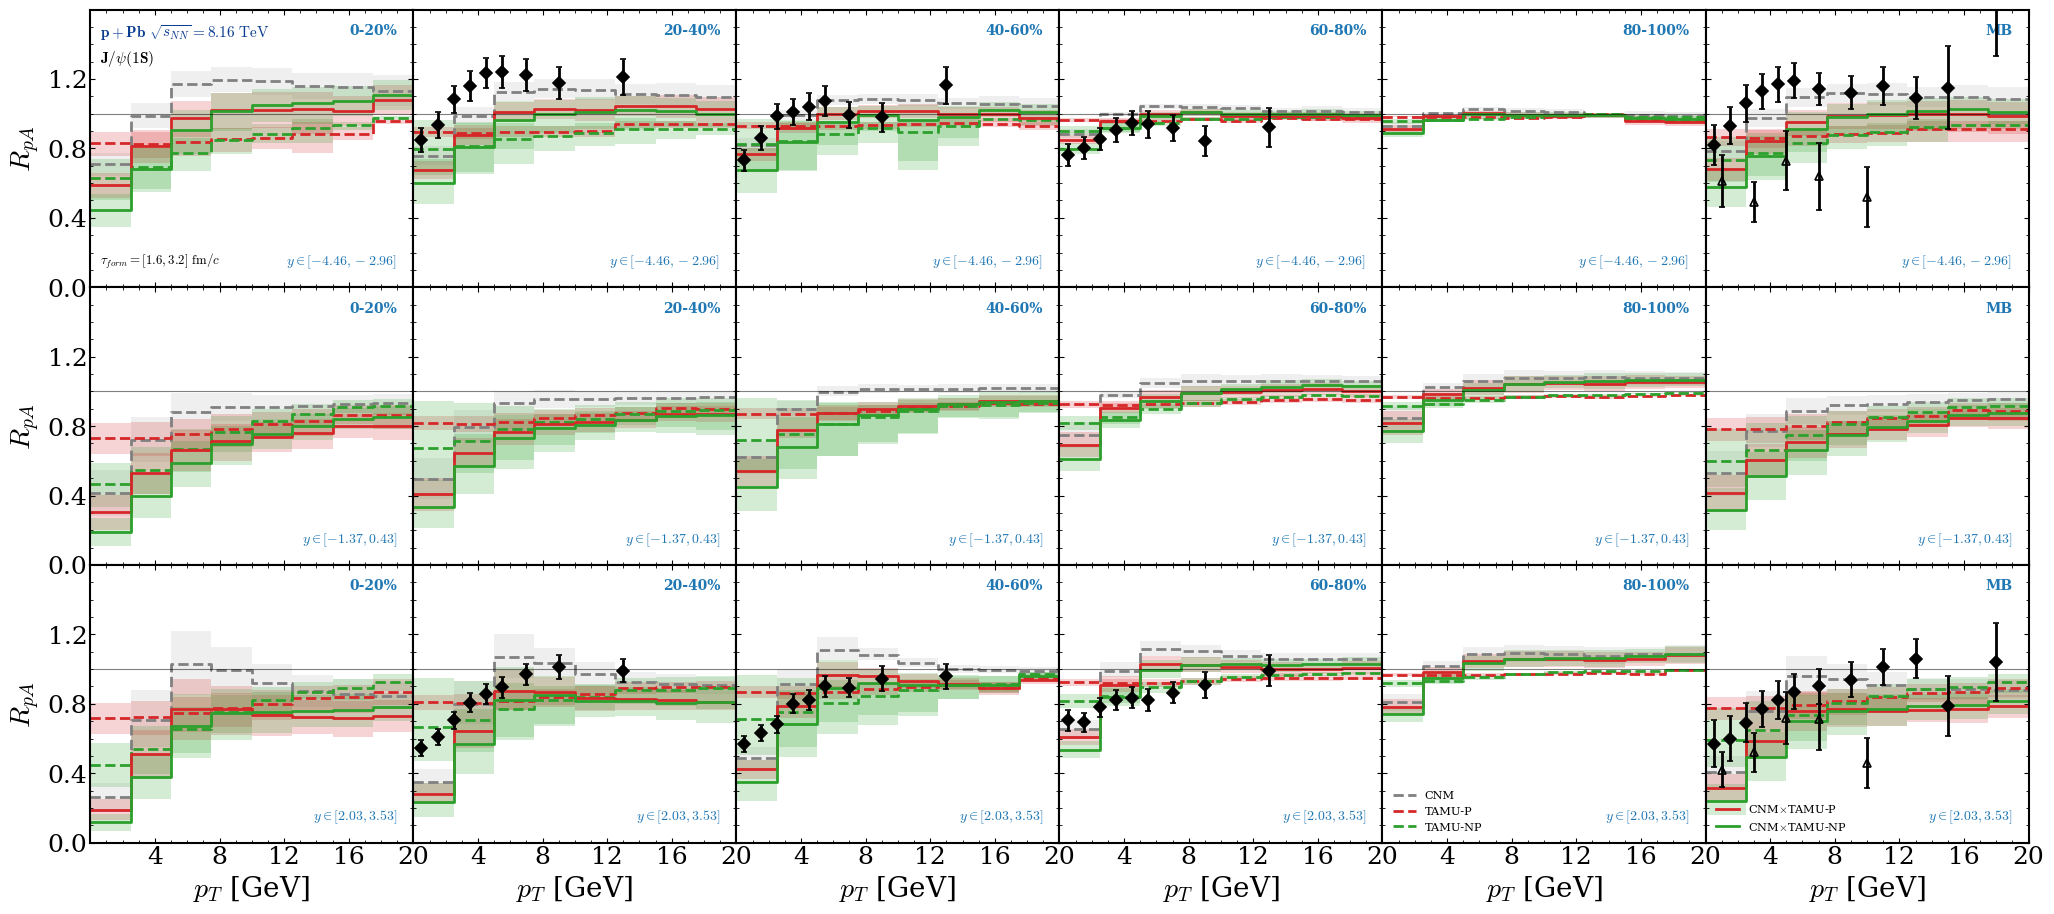

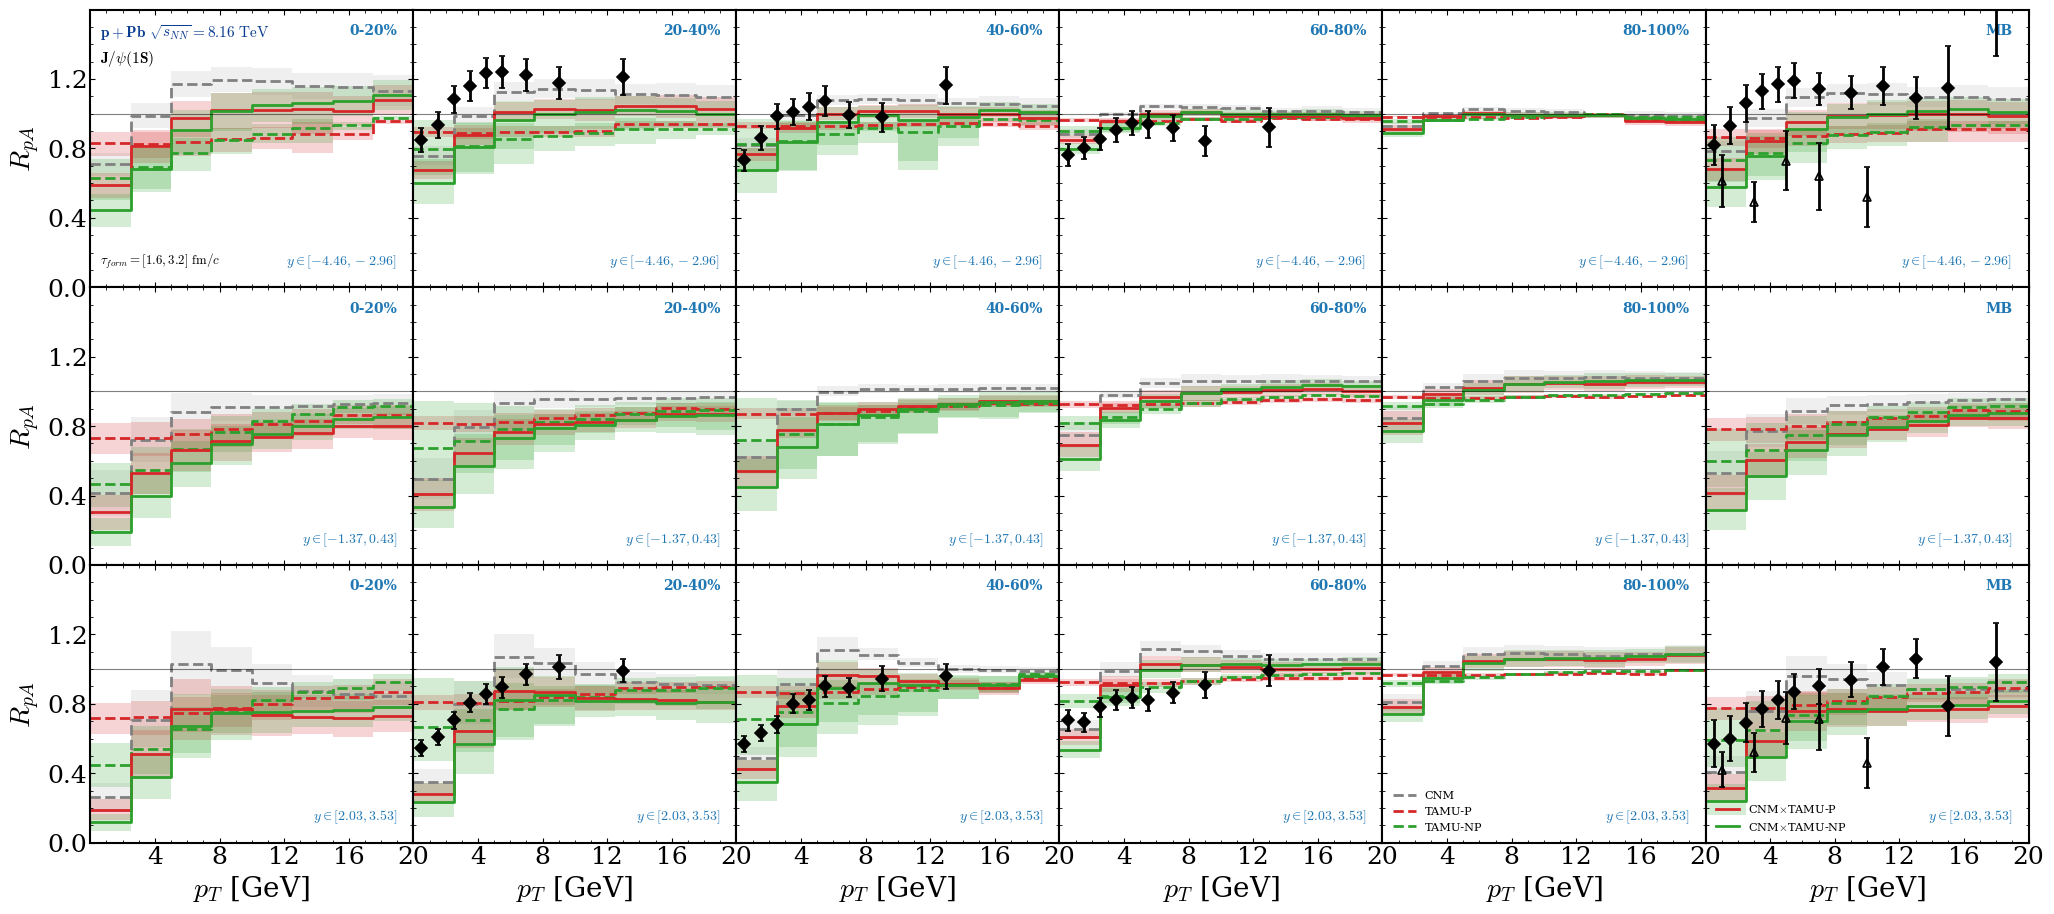

In [9]:

# Master grid (rapidity x centrality)
if PT_MASTERGRID:
    if SYSTEM == 'LHC':
        st = STATES[0]
        fig, rows = pub.plot_state_vs_pt_mastergrid(
            setup=setup,
            formation=FORMATION,
            state=st,
            cnm=cnm_by_state[st],
            prim=prim,
            include_primordial=INCLUDE_PRIMORDIAL,
            include_combined=INCLUDE_COMBINED,
            show_cnm_components=SHOW_CNM_COMPONENTS,
            show_alt_cnm=SHOW_ALT_CNM,
            band_mode=BAND_MODE,
            include_experiment=INCLUDE_EXPERIMENT,
            xlim=PT_MASTERGRID_XLIM,
            ylim=PT_MASTERGRID_YLIM,
            note_loc_first=PT_NOTE_LOC_FIRST,
            legend_split=PT_MASTERGRID_LEGEND_SPLIT,
            legend_fontsize=LEGEND_FONT_SIZE,
            legend_bold=False,
            text_style=TEXT_STYLE_OVERRIDES,
        )
        if INCLUDE_EXPERIMENT and len(STATES) > 1:
            cent_tags = [pub.canonical_cent(f"{a}-{b}%") for (a, b) in setup.cent_bins] + ['MB']
            nrows = len(setup.y_windows)
            ncols = len(cent_tags)
            axes_arr = np.array(fig.axes).reshape((nrows, ncols))
            for irow, (_, y0, y1) in enumerate(pub.iter_ywins(setup.y_windows)):
                for jcol, cent_tag in enumerate(cent_tags):
                    ax = axes_arr[irow, jcol]
                    if cent_tag == 'MB':
                        pub.overlay_lhc_state(ax, 'vs_pt', ENERGY, 'psi_2S', rap_window=(y0, y1), cent_tag='MB')
                    else:
                        pub.overlay_lhc_state(ax, 'vs_pt_cent', ENERGY, 'psi_2S', rap_window=(y0, y1), cent_tag=cent_tag)
        pub.save_figure(fig, out_root / 'RpA_vs_pT_MasterGrid', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
        rows_pt.extend(rows)
        display(fig)
    else:
        for st in STATES:
            fig, rows = pub.plot_state_vs_pt_mastergrid(
                setup=setup,
                formation=FORMATION,
                state=st,
                cnm=cnm_by_state[st],
                prim=prim,
                include_primordial=INCLUDE_PRIMORDIAL,
                include_combined=INCLUDE_COMBINED,
                show_cnm_components=SHOW_CNM_COMPONENTS,
                show_alt_cnm=SHOW_ALT_CNM,
                band_mode=BAND_MODE,
                include_experiment=INCLUDE_EXPERIMENT,
                xlim=PT_MASTERGRID_XLIM,
                ylim=PT_MASTERGRID_YLIM,
                note_loc_first=PT_NOTE_LOC_FIRST,
                legend_split=PT_MASTERGRID_LEGEND_SPLIT,
                legend_fontsize=LEGEND_FONT_SIZE,
                legend_bold=False,
                text_style=TEXT_STYLE_OVERRIDES,
            )
            pub.save_figure(fig, out_root / f'RpA_vs_pT_MasterGrid_{st}', save_pdf=SAVE_PDF, save_png=SAVE_PNG)
            rows_pt.extend(rows)
            display(fig)


## Step 8: Export Consolidated CSV + Quick Output Check


In [10]:
rows_all = rows_cent + rows_y + rows_pt
csv_path = out_root / f'combined_curves_LHC_{ENERGY.replace('.', 'p')}TeV_{FORMATION}.csv'
pub.save_rows_csv(rows_all, csv_path)
print('Saved CSV:', csv_path)

files = sorted([p.name for p in out_root.glob('*')])
print('Generated files:', len(files))
for nm in files[:40]:
    print('-', nm)


Saved CSV: /home/sawin/Desktop/Charmonia/charmonia_combined_analysis/outputs/combined_cnm_primordial_experimental/LHC_8p16TeV/radius/step_by_step/combined_curves_LHC_8p16TeV_radius.csv
Generated files: 19
- RpA_vs_centrality.pdf
- RpA_vs_centrality_jpsi_1S.pdf
- RpA_vs_centrality_psi_2S.pdf
- RpA_vs_pT_MasterGrid.pdf
- RpA_vs_pT_MasterGrid_jpsi_1S.pdf
- RpA_vs_pT_MasterGrid_psi_2S.pdf
- RpA_vs_pT_backward.pdf
- RpA_vs_pT_central.pdf
- RpA_vs_pT_forward.pdf
- RpA_vs_pT_jpsi_1S_backward.pdf
- RpA_vs_pT_jpsi_1S_central.pdf
- RpA_vs_pT_jpsi_1S_forward.pdf
- RpA_vs_pT_psi_2S_backward.pdf
- RpA_vs_pT_psi_2S_central.pdf
- RpA_vs_pT_psi_2S_forward.pdf
- RpA_vs_y.pdf
- RpA_vs_y_jpsi_1S.pdf
- RpA_vs_y_psi_2S.pdf
- combined_curves_LHC_8p16TeV_radius.csv
